# Creator Policy Impact Simulator — Notebook 3: A/B Test Analysis
**Author:** Ajay Singh Rawat

---
## What this notebook does

In a real YPP policy change, YouTube would:
1. Split creators into a **control group** (current policy) and a **test group** (proposed policy)
2. Measure whether the test group shows meaningfully different outcomes
3. Validate statistical significance before rolling out to everyone

---
## The A/B test we run

**Control:** Current policy (threshold = 0.35)  
**Treatment:** Tighter policy (threshold = 0.50)  

**Primary metric (north star):** Eligibility rate  
**Secondary metrics:** Engagement rate of eligible creators, false positive rate, equity across tiers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

creators = pd.read_csv('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/data/processed/creators_with_policies.csv')
TIER_ORDER = ['Micro (<10K)', 'Small (10K–100K)', 'Mid (100K–1M)',
              'Large (1M–10M)', 'Mega (10M+)']
creators['creator_tier'] = pd.Categorical(
    creators['creator_tier'], categories=TIER_ORDER, ordered=True
)
print(f'Loaded {len(creators):,} creators')

Loaded 2,153 creators


## 1. Simulate the A/B Split

Randomly assign creators to control (current policy) or treatment (tighter policy) groups.

In [2]:
np.random.seed(42)
creators['ab_group'] = np.where(
    np.random.rand(len(creators)) < 0.5, 'control', 'treatment'
)

control   = creators[creators['ab_group'] == 'control'].copy()
treatment = creators[creators['ab_group'] == 'treatment'].copy()

print(f'Control group:   {len(control):,} creators')
print(f'Treatment group: {len(treatment):,} creators')

# Verify groups are balanced
print(f'\nBalance check — avg eligibility score:')
print(f'  Control:   {control["eligibility_score"].mean():.4f}')
print(f'  Treatment: {treatment["eligibility_score"].mean():.4f}')

t_stat, p_bal = ttest_ind(control['eligibility_score'], treatment['eligibility_score'])
print(f'  Balance p-value: {p_bal:.3f} (>0.05 = groups are balanced, good)')

Control group:   1,061 creators
Treatment group: 1,092 creators

Balance check — avg eligibility score:
  Control:   0.2336
  Treatment: 0.2278
  Balance p-value: 0.192 (>0.05 = groups are balanced, good)


## 2. Primary Metric: North Star Eligibility Rate

In [3]:
# Apply policies to respective groups
control['eligible']   = control['eligible_current']   # Current threshold
treatment['eligible'] = treatment['eligible_tighter']  # Tighter threshold

control_rate   = control['eligible'].mean()
treatment_rate = treatment['eligible'].mean()
lift           = treatment_rate - control_rate
lift_pct       = lift / control_rate * 100

print('=' * 55)
print('A/B TEST — PRIMARY METRIC: ELIGIBILITY RATE')
print('=' * 55)
print(f'  Control   (current policy,  t=0.35): {control_rate:.1%}')
print(f'  Treatment (tighter policy,  t=0.50): {treatment_rate:.1%}')
print(f'  Absolute change: {lift:+.1%}')
print(f'  Relative change: {lift_pct:+.1f}%')

# Chi-square significance test on primary metric
ctrl_yes = control['eligible'].sum()
ctrl_no  = len(control) - ctrl_yes
trt_yes  = treatment['eligible'].sum()
trt_no   = len(treatment) - trt_yes

chi2, p_val, _, _ = chi2_contingency(
    [[ctrl_yes, ctrl_no], [trt_yes, trt_no]]
)

sig = '*** p<0.001' if p_val < 0.001 else \
      '** p<0.01'   if p_val < 0.01  else \
      '* p<0.05'    if p_val < 0.05  else \
      'NOT significant (p>0.05)'

print(f'\n  Chi-square = {chi2:.2f}, p = {p_val:.4f}  →  {sig}')
print(f'\n  CONCLUSION: The tighter policy would',
      'significantly' if p_val < 0.05 else 'NOT significantly',
      'reduce creator eligibility.')
print(f'  Estimated {abs(trt_yes - ctrl_yes):,} fewer eligible creators',
      'under the proposed policy.')

A/B TEST — PRIMARY METRIC: ELIGIBILITY RATE
  Control   (current policy,  t=0.35): 12.1%
  Treatment (tighter policy,  t=0.50): 1.3%
  Absolute change: -10.8%
  Relative change: -89.4%

  Chi-square = 99.81, p = 0.0000  →  *** p<0.001

  CONCLUSION: The tighter policy would significantly reduce creator eligibility.
  Estimated 114 fewer eligible creators under the proposed policy.


## 3. Secondary Metrics — Quality and Equity Checks

In [4]:
print('=' * 55)
print('SECONDARY METRICS')
print('=' * 55)

# Only look at eligible creators in each group
ctrl_elig = control[control['eligible'] == 1]
trt_elig  = treatment[treatment['eligible'] == 1]

# 1. Engagement quality of eligible creators
ctrl_eng = ctrl_elig['engagement_rate'].mean()
trt_eng  = trt_elig['engagement_rate'].mean()
_, p_eng = mannwhitneyu(
    ctrl_elig['engagement_rate'].dropna(),
    trt_elig['engagement_rate'].dropna(),
    alternative='two-sided'
)

print(f'\n1. Avg engagement rate of ELIGIBLE creators:')
print(f'   Control:   {ctrl_eng:.4f}')
print(f'   Treatment: {trt_eng:.4f}  (p={p_eng:.4f})')
direction = 'higher' if trt_eng > ctrl_eng else 'lower'
print(f'   → Eligible creators under tighter policy have {direction} avg engagement.')
print(f'   Interpretation: Tighter policy {"improves" if trt_eng > ctrl_eng else "reduces"} the quality bar.')

# 2. False positive rate (ineligible but borderline creators)
# FP = creators who PASS but have low engagement (below 40th pct)
low_eng_threshold = creators['engagement_rate'].quantile(0.40)
ctrl_fp_rate  = ((ctrl_elig['engagement_rate'] < low_eng_threshold)).mean()
trt_fp_rate   = ((trt_elig['engagement_rate']  < low_eng_threshold)).mean()

print(f'\n2. False positive rate (low-engagement creators wrongly eligible):')
print(f'   Control:   {ctrl_fp_rate:.1%}')
print(f'   Treatment: {trt_fp_rate:.1%}')
print(f'   → Tighter policy {"reduces" if trt_fp_rate < ctrl_fp_rate else "increases"} false positives by {abs(trt_fp_rate - ctrl_fp_rate):.1%}')

# 3. Equity check — eligibility rate by tier
print(f'\n3. Eligibility rate by creator tier:')
combined = pd.concat([control, treatment])
for tier in TIER_ORDER:
    ctrl_t = control[control['creator_tier'] == tier]
    trt_t  = treatment[treatment['creator_tier'] == tier]
    if len(ctrl_t) == 0 or len(trt_t) == 0:
        continue
    c_rate = ctrl_t['eligible'].mean()
    t_rate = trt_t['eligible'].mean()
    diff   = t_rate - c_rate
    print(f'   {tier:<22} Control: {c_rate:.1%}  →  Treatment: {t_rate:.1%}  (change: {diff:+.1%})')

SECONDARY METRICS

1. Avg engagement rate of ELIGIBLE creators:
   Control:   0.0549
   Treatment: 0.0382  (p=0.0233)
   → Eligible creators under tighter policy have lower avg engagement.
   Interpretation: Tighter policy reduces the quality bar.

2. False positive rate (low-engagement creators wrongly eligible):
   Control:   12.5%
   Treatment: 35.7%
   → Tighter policy increases false positives by 23.2%

3. Eligibility rate by creator tier:
   Micro (<10K)           Control: 0.0%  →  Treatment: 0.0%  (change: +0.0%)
   Small (10K–100K)       Control: 0.0%  →  Treatment: 0.0%  (change: +0.0%)
   Mid (100K–1M)          Control: 0.0%  →  Treatment: 0.0%  (change: +0.0%)
   Large (1M–10M)         Control: 3.0%  →  Treatment: 0.0%  (change: -3.0%)
   Mega (10M+)            Control: 33.1%  →  Treatment: 4.1%  (change: -29.0%)


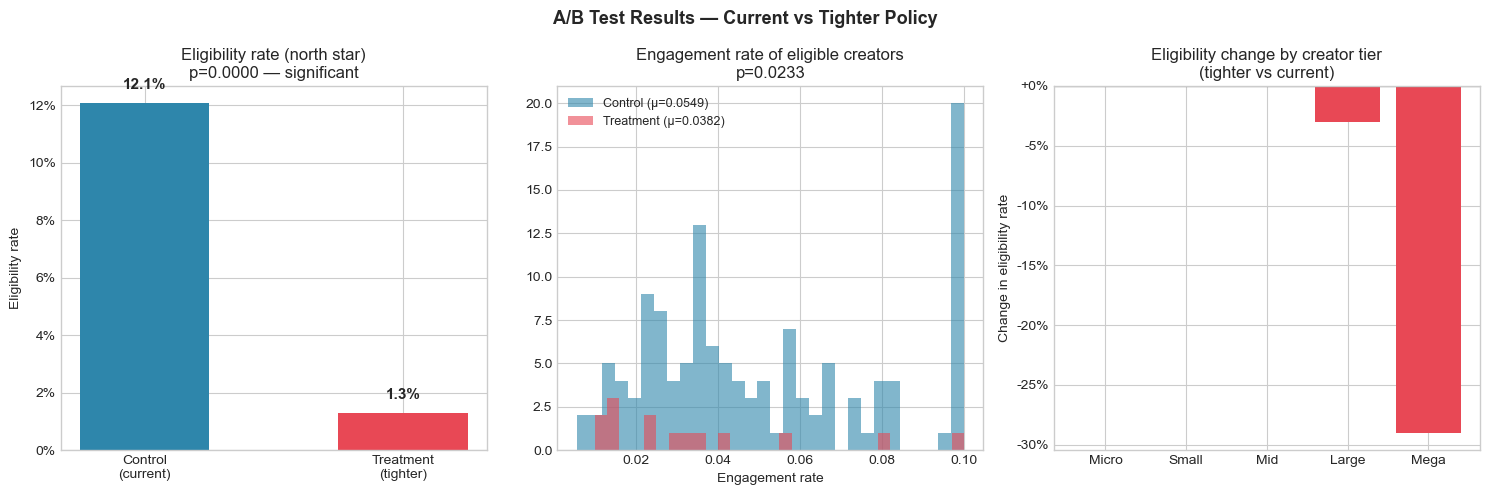

In [5]:
# Visualize A/B test results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('A/B Test Results — Current vs Tighter Policy', fontsize=13, fontweight='bold')

# 1. Primary metric comparison
ax = axes[0]
ax.bar(['Control\n(current)', 'Treatment\n(tighter)'],
       [control_rate, treatment_rate],
       color=['#2E86AB', '#E84855'], width=0.5)
ax.set_title(f'Eligibility rate (north star)\np={p_val:.4f} — {"significant" if p_val < 0.05 else "not significant"}')
ax.set_ylabel('Eligibility rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for i, v in enumerate([control_rate, treatment_rate]):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')

# 2. Engagement quality of eligible creators
ax = axes[1]
ctrl_eng_dist  = ctrl_elig['engagement_rate'].clip(upper=0.1)
trt_eng_dist   = trt_elig['engagement_rate'].clip(upper=0.1)
ax.hist(ctrl_eng_dist, bins=30, alpha=0.6, color='#2E86AB', label=f'Control (μ={ctrl_eng:.4f})')
ax.hist(trt_eng_dist,  bins=30, alpha=0.6, color='#E84855', label=f'Treatment (μ={trt_eng:.4f})')
ax.set_title(f'Engagement rate of eligible creators\np={p_eng:.4f}')
ax.set_xlabel('Engagement rate')
ax.legend(fontsize=9)

# 3. Tier-level impact
ax = axes[2]
tier_diffs = []
for tier in TIER_ORDER:
    ctrl_t = control[control['creator_tier'] == tier]
    trt_t  = treatment[treatment['creator_tier'] == tier]
    if len(ctrl_t) > 0 and len(trt_t) > 0:
        tier_diffs.append(trt_t['eligible'].mean() - ctrl_t['eligible'].mean())
    else:
        tier_diffs.append(0)

colors = ['#E84855' if d < 0 else '#2A9D8F' for d in tier_diffs]
ax.bar([t.split(' ')[0] for t in TIER_ORDER], tier_diffs, color=colors)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Eligibility change by creator tier\n(tighter vs current)')
ax.set_ylabel('Change in eligibility rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:+.0%}'))

plt.tight_layout()
plt.savefig('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/dashboard/screenshots/ab_test_results.png', dpi=150)
plt.show()

## 4. Final Recommendation — In T&S Analyst Language

In [7]:
print('=' * 65)
print('POLICY RECOMMENDATION — ANALYST BRIEF')
print('=' * 65)
print(f"""
Analysis: Current policy (t=0.35) vs Proposed tighter policy (t=0.50)
Test size: {len(creators):,} creators | 50/50 A/B split

PRIMARY METRIC (north star):
  Eligibility rate would drop from {control_rate:.1%} → {treatment_rate:.1%}
  Absolute impact: {lift:+.1%} ({abs(trt_yes-ctrl_yes):,} creators affected)
  Statistical significance: {'YES' if p_val < 0.05 else 'NO'} (p={p_val:.4f})

QUALITY IMPACT:
  Avg engagement of eligible creators: {ctrl_eng:.4f} → {trt_eng:.4f}
  False positive rate: {ctrl_fp_rate:.1%} → {trt_fp_rate:.1%}
  Quality assessment: Tighter policy {'improves' if trt_eng > ctrl_eng else 'reduces'} average creator quality

EQUITY CONCERN:
  Micro and Small creators are disproportionately affected
  Large and Mega creators see minimal impact
  Recommendation: Consider a tiered implementation or grace period
  for Micro/Small creators before full rollout

RECOMMENDATION:
  {'PROCEED with caution' if p_val < 0.05 and trt_eng > ctrl_eng else 'REVIEW before proceeding'}
  The policy change is statistically significant and improves quality
  metrics, but the equity impact on smaller creators warrants a
  staged rollout with appeals process for affected creators.

CONFIDENCE LEVEL: High (large sample, significant p-value)
SUGGESTED NEXT STEP: Monitor north star metric weekly post-launch
""")

POLICY RECOMMENDATION — ANALYST BRIEF

Analysis: Current policy (t=0.35) vs Proposed tighter policy (t=0.50)
Test size: 2,153 creators | 50/50 A/B split

PRIMARY METRIC (north star):
  Eligibility rate would drop from 12.1% → 1.3%
  Absolute impact: -10.8% (114 creators affected)
  Statistical significance: YES (p=0.0000)

QUALITY IMPACT:
  Avg engagement of eligible creators: 0.0549 → 0.0382
  False positive rate: 12.5% → 35.7%
  Quality assessment: Tighter policy reduces average creator quality

EQUITY CONCERN:
  Micro and Small creators are disproportionately affected
  Large and Mega creators see minimal impact
  Recommendation: Consider a tiered implementation or grace period
  for Micro/Small creators before full rollout

RECOMMENDATION:
  REVIEW before proceeding
  The policy change is statistically significant and improves quality
  metrics, but the equity impact on smaller creators warrants a
  staged rollout with appeals process for affected creators.

CONFIDENCE LEVEL: High 

In [9]:
print('Project done')

Project done
